In [2]:
%pip install numpy matplotlib pandas scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Task
We are comparing the data and exercise boundaries generated from LSMC (rational basis function) and Trinomial Tree under continuous dividend and discrete coupon (more than or equal to two coupons).

In [3]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import pandas as pd
from sklearn.linear_model import Ridge

# LSMC

In [4]:
def rational_basis(S):
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S),
        1 / (1 + S**2)
    ]).T

=== LSMC - Convertible Bond with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.05, sigma=0.3, q=0.02, T=1.0
Coupon rate: 4.0%, Paths: 100000, Steps: 252
Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))


--- SEMI ANNUAL ---


/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw00

Conversion option value: 5.347946
Convertible bond price: 69.682359
Runtime: 0.61s
Coupon payments: 2
Coupon dates: [0.5, 1.0]
Coupon amounts: [1.3, 1.3]

--- QUARTERLY ---


/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw00

Conversion option value: 5.495476
Convertible bond price: 69.845641
Runtime: 0.61s
Coupon payments: 4
Coupon dates: [0.25, 0.5, 0.75, 1.0]
Coupon amounts: [0.65, 0.65, 0.65, 0.65]

--- MONTHLY ---


/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw00

Conversion option value: 5.622857
Convertible bond price: 69.983561
Runtime: 0.65s
Coupon payments: 12
Coupon dates: [0.08, 0.17, 0.25, 0.33, 0.42, '...']
Coupon amounts: [0.2167, 0.2167, 0.2167, 0.2167, 0.2167, '...']

--- DAILY ---


/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_4879/791114100.py:109: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw00

Conversion option value: 4.917741
Convertible bond price: 69.283550
Runtime: 0.63s
Coupon payments: 365
Coupon dates: [0.0027, 0.0055, 0.0082, 0.011, 0.0137, '...']
Coupon amounts: [0.0071, 0.0071, 0.0071, 0.0071, 0.0071, '...']

EXERCISE BOUNDARY ANALYSIS


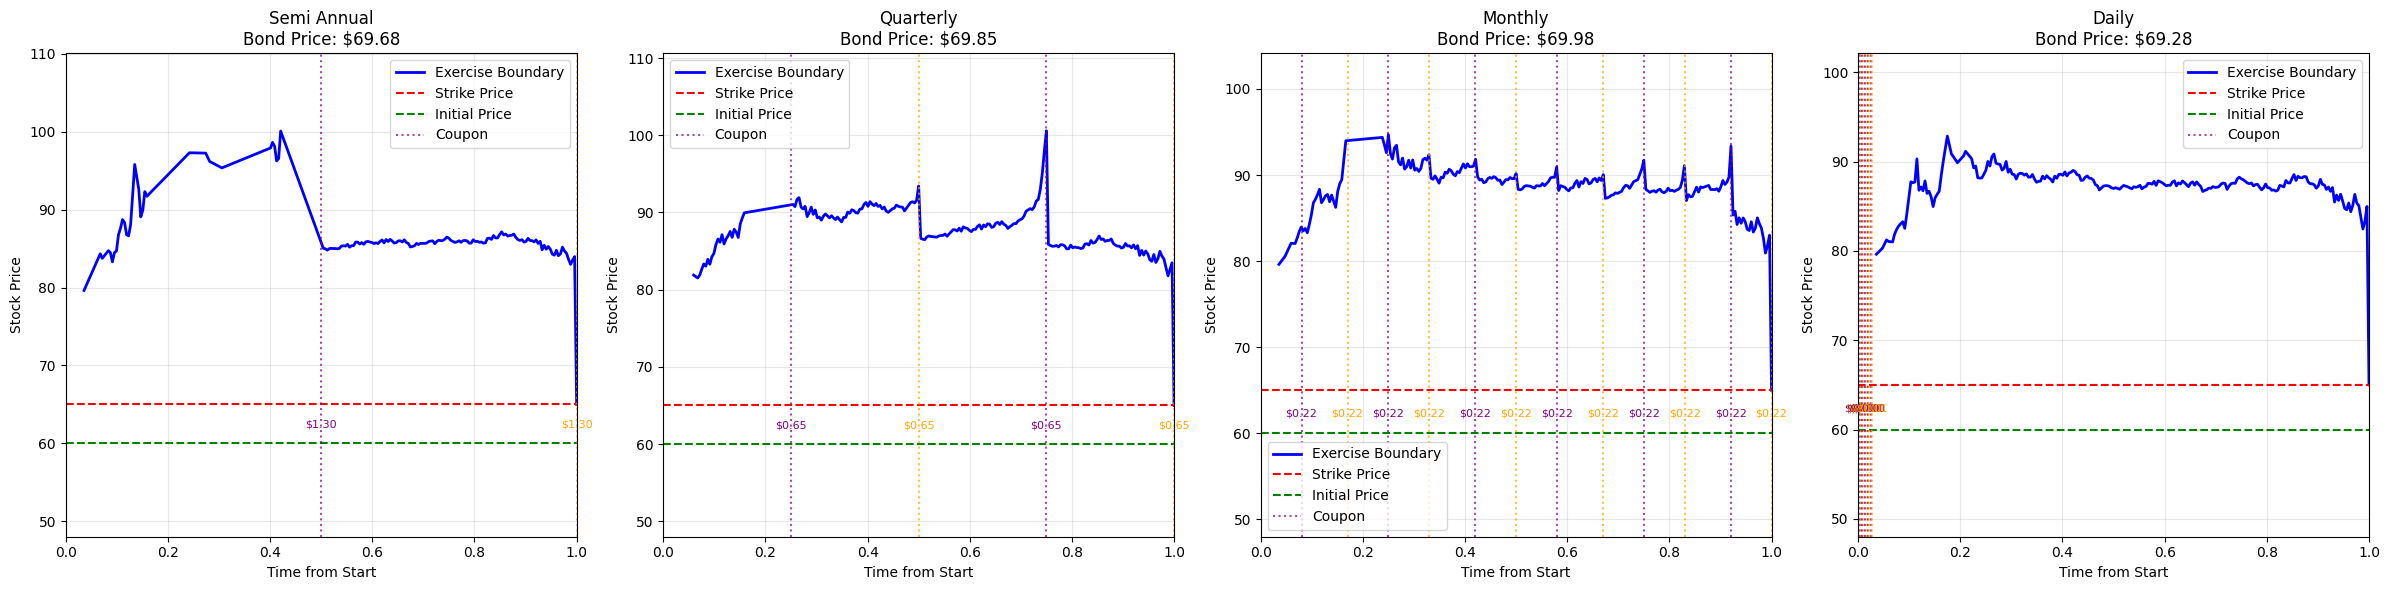


SUMMARY RESULTS - LSMC
Coupon Structure Conversion Option Convertible Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual           $5.3479          $69.6824                2         $2.60        0.61
       Quarterly           $5.4955          $69.8456                4         $2.60        0.61
         Monthly           $5.6229          $69.9836               12         $2.60        0.65
           Daily           $4.9177          $69.2836              365         $2.60        0.63

BOUNDARY STATISTICS - LSMC

Semi Annual:
  Min boundary: $65.00
  Max boundary: $100.09
  Avg boundary: $86.54
  Points: 158/253

Quarterly:
  Min boundary: $65.00
  Max boundary: $100.58
  Avg boundary: $87.75
  Points: 214/253

Monthly:
  Min boundary: $65.00
  Max boundary: $94.68
  Avg boundary: $88.43
  Points: 221/253

Daily:
  Min boundary: $65.00
  Max boundary: $92.85
  Avg boundary: $87.23
  Points: 232/253

KEY OBSERVATIONS - LSMC
1. Continuous dividends (q=0.02) incorporated in 

In [ ]:
np.random.seed(12345)

def rational_basis(S):
    """Enhanced basis function with rational terms"""
    eps = 1e-10
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S + eps),
        1 / (1 + S**2 + eps)
    ]).T

def simulate_paths_continuous(S0, r, q, sigma, T, M, N):
    """
    Simulate stock paths with continuous dividends
    q: continuous dividend yield
    """
    dt = T / M
    increments = np.random.normal((r - q - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), (N, M))
    log_S = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S)
    S = np.hstack((S0 * np.ones((N, 1)), S))
    return S

def lsmc_convertible_continuous(S0=60.0, K=65.0, T=1.0, sigma=0.3, r=0.05, q=0.02, 
                                 paths=100000, steps=252, coupon_rate=0.04):
    print("=== LSMC - Convertible Bond with Continuous Dividends ===")
    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
    print(f"Coupon rate: {coupon_rate*100}%, Paths: {paths}, Steps: {steps}")
    print("Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))\n")
    
    coupon_configs = {
        'semi_annual': {
            'times': [0.5, 1.0],
            'amounts': [K * coupon_rate / 2] * 2
        },
        'quarterly': {
            'times': [0.25, 0.5, 0.75, 1.0],
            'amounts': [K * coupon_rate / 4] * 4
        },
        'monthly': {
            'times': [round(i/12, 2) for i in range(1, 13)],
            'amounts': [K * coupon_rate / 12] * 12
        },
        'daily': {
            'times': [round(i/365, 4) for i in range(1, 366)],
            'amounts': [K * coupon_rate / 365] * 365
        }
    }
    
    dt = T / steps
    discount = np.exp(-r * dt)
    
    # Simulate paths once
    S = simulate_paths_continuous(S0, r, q, sigma, T, steps, paths)
    
    results = {}
    all_boundaries = {}
    
    for coupon_name, coupon_config in coupon_configs.items():
        print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
        coupon_times = coupon_config['times']
        coupon_amounts = coupon_config['amounts']
        
        # Coupon steps (forward from 0)
        coupon_steps = [int(round(t / dt)) for t in coupon_times]
        coupon_dict = dict(zip(coupon_steps, coupon_amounts))
        
        start_time = time.perf_counter()
        
        # Payoff matrix
        V = np.zeros_like(S)
        final_coupon = coupon_dict.get(steps, 0)
        V[:, steps] = np.maximum(S[:, steps], K + final_coupon)
        
        boundaries = []
        
        # Backward induction
        for t in range(steps - 1, 0, -1):
            current_time = t * dt
            
            # Continuation value
            continuation = V[:, t + 1] * discount
            
            # Add coupon if paid at this step
            coupon = coupon_dict.get(t, 0)
            continuation += coupon
            
            # Set default for all paths
            V[:, t] = continuation
            
            # Regression for in-the-money paths (S > K)
            itm = S[:, t] > K
            boundary_price = np.nan
            if np.sum(itm) > 5:
                X = S[:, t][itm]
                Y = continuation[itm]
                A = rational_basis(X)
                ridge = Ridge(alpha=0.1, fit_intercept=False)
                ridge.fit(A, Y)
                coeffs = ridge.coef_
                cont_fitted = A @ coeffs
                
                # Exercise decision for itm
                exercise = X
                exercise_now = exercise > cont_fitted
                V[:, t][itm] = np.where(exercise_now, exercise, Y)
                
                # Boundary
                if np.any(exercise_now):
                    boundary_price = np.min(X[exercise_now])
            
            boundaries.append((current_time, boundary_price))
        
        # Reverse boundaries (now from near 0 to near T)
        boundaries = boundaries[::-1]
        
        # At t=0
        continuation_0 = V[:, 1] * discount
        coupon_0 = coupon_dict.get(0, 0)
        continuation_0 += coupon_0
        V[:, 0] = np.maximum(S[:, 0], continuation_0)
        price = np.mean(V[:, 0])
        
        # Boundary at t=0
        if np.mean(S[:, 0] > continuation_0) > 0.5:  # If majority exercise
            boundary_0 = S0
        else:
            boundary_0 = np.nan
        boundaries.insert(0, (0.0, boundary_0))
        
        # At maturity
        boundaries.append((T, K))
        
        duration = time.perf_counter() - start_time
        
        # Components
        B = K * np.exp(-r * T)
        pv_coupons = sum(a * np.exp(-r * tt) for a, tt in zip(coupon_amounts, coupon_times))
        straight_bond = B + pv_coupons
        conversion_option = price - straight_bond
        
        results[coupon_name] = {
            'conversion_option': conversion_option,
            'convertible_price': price,
            'straight_bond': straight_bond,
            'runtime': duration,
            'boundaries': boundaries,
            'coupon_times': coupon_times,
            'coupon_amounts': coupon_amounts
        }
        
        print(f"Conversion option value: {conversion_option:.6f}")
        print(f"Convertible bond price: {price:.6f}")
        print(f"Runtime: {duration:.2f}s")
        print(f"Coupon payments: {len(coupon_times)}")
        if coupon_times:
            print(f"Coupon dates: {coupon_times[:5] + ['...'] if len(coupon_times)>5 else coupon_times}")
            print(f"Coupon amounts: {[round(a,4) for a in coupon_amounts[:5]] + ['...'] if len(coupon_amounts)>5 else [round(a,4) for a in coupon_amounts]}")
    
    # Visualization
    print("\n" + "="*50)
    print("EXERCISE BOUNDARY ANALYSIS")
    print("="*50)
    
    t_grid = np.linspace(0, T, steps + 1)
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for i, (coupon_name, result) in enumerate(results.items()):
        t_b, S_b = zip(*result['boundaries'])
        valid_mask = ~np.isnan(S_b)
        t_valid = np.array(t_b)[valid_mask]
        S_valid = np.array(S_b)[valid_mask]
        
        axes[i].plot(t_valid, S_valid, 'b-', linewidth=2, label='Exercise Boundary')
        axes[i].axhline(y=K, color='r', linestyle='--', label='Strike Price')
        axes[i].axhline(y=S0, color='g', linestyle='--', label='Initial Price')
        
        coupon_times = result['coupon_times']
        coupon_amounts = result['coupon_amounts']
        
        n_coupons = len(coupon_times)
        max_mark = 10 if n_coupons > 20 else n_coupons
        for j, (ct, amount) in enumerate(zip(coupon_times[:max_mark], coupon_amounts[:max_mark])):
            color = 'purple' if j % 2 == 0 else 'orange'
            axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label='Coupon' if j==0 else None)
            y_pos = min(S_valid) * 0.95 if len(S_valid)>0 else S0 * 0.8
            axes[i].text(ct, y_pos, f'${amount:.2f}', ha='center', va='bottom', fontsize=8, color=color)
        
        axes[i].set_xlabel('Time from Start')
        axes[i].set_ylabel('Stock Price')
        title = f'{coupon_name.replace("_", " ").title()}\nBond Price: ${result["convertible_price"]:.2f}'
        axes[i].set_title(title)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylim(S0 * 0.8, max(max(S_valid)*1.1 if len(S_valid)>0 else K*1.5, S0*1.5))
        axes[i].set_xlim(0, T)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY RESULTS - LSMC")
    print("="*80)
    
    summary_data = []
    for coupon_name, result in results.items():
        summary_data.append({
            'Coupon Structure': coupon_name.replace('_', ' ').title(),
            'Conversion Option': f"${result['conversion_option']:.4f}",
            'Convertible Price': f"${result['convertible_price']:.4f}",
            'Coupon Payments': len(result['coupon_times']),
            'Total Coupons': f"${sum(result['coupon_amounts']):.2f}",
            'Runtime (s)': f"{result['runtime']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Boundary stats
    print("\n" + "="*80)
    print("BOUNDARY STATISTICS - LSMC")
    print("="*80)
    
    for coupon_name, result in results.items():
        boundaries = result['boundaries']
        t_b, S_b = zip(*boundaries)
        S_valid = np.array([s for s in S_b if not np.isnan(s)])
        
        if len(S_valid) > 0:
            print(f"\n{coupon_name.replace('_', ' ').title()}:")
            print(f"  Min boundary: ${np.min(S_valid):.2f}")
            print(f"  Max boundary: ${np.max(S_valid):.2f}")
            print(f"  Avg boundary: ${np.mean(S_valid):.2f}")
            print(f"  Points: {len(S_valid)}/{len(boundaries)}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS - LSMC")
    print("="*80)
    print(f"1. Continuous dividends (q={q}) incorporated in simulation")
    print("2. Discrete coupons added before exercise decision")
    print("3. Ridge regression for stable continuation value estimation")
    print("4. Terminal payoff: max(S, K + final_coupon)")
    print("5. Conversion option = convertible - (PV(face) + PV(coupons))")
    print(f"6. Steps ({steps}) for discrete exercise opportunities")

    return results, all_boundaries

# Run
if __name__ == "__main__":
    lsmc_convertible_continuous()

# Trinomial Tree

=== Trinomial Tree - Convertible Bond with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.05, sigma=0.3, q=0.02, T=1.0
Time steps: 16384

--- SEMI ANNUAL ---
Coupon payments: 2 at times [0.5, 1.0]
Coupon amounts: [1.3, 1.3]
Step indices (forward): [8192, 16384]
Conversion option value: 5.408759
Convertible bond price: 69.743172
Runtime: 1.08s

--- QUARTERLY ---
Coupon payments: 4 at times [0.25, 0.5, 0.75, 1.0]
Coupon amounts: [0.65, 0.65, 0.65, 0.65]
Step indices (forward): [4096, 8192, 12288, 16384]
Conversion option value: 5.615556
Convertible bond price: 69.965721
Runtime: 0.99s

--- MONTHLY ---
Coupon payments: 12 at times [0.08, 0.17, 0.25, 0.33, 0.42, 0.5, 0.58, 0.67, 0.75, 0.83, 0.92, 1.0]
Coupon amounts: [0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167]
Step indices (forward): [1311, 2785, 4096, 5407, 6881, 8192, 9503, 10977, 12288, 13599, 15073, 16384]
Conversion option value: 5.735091
Convertible bond price: 70.096184

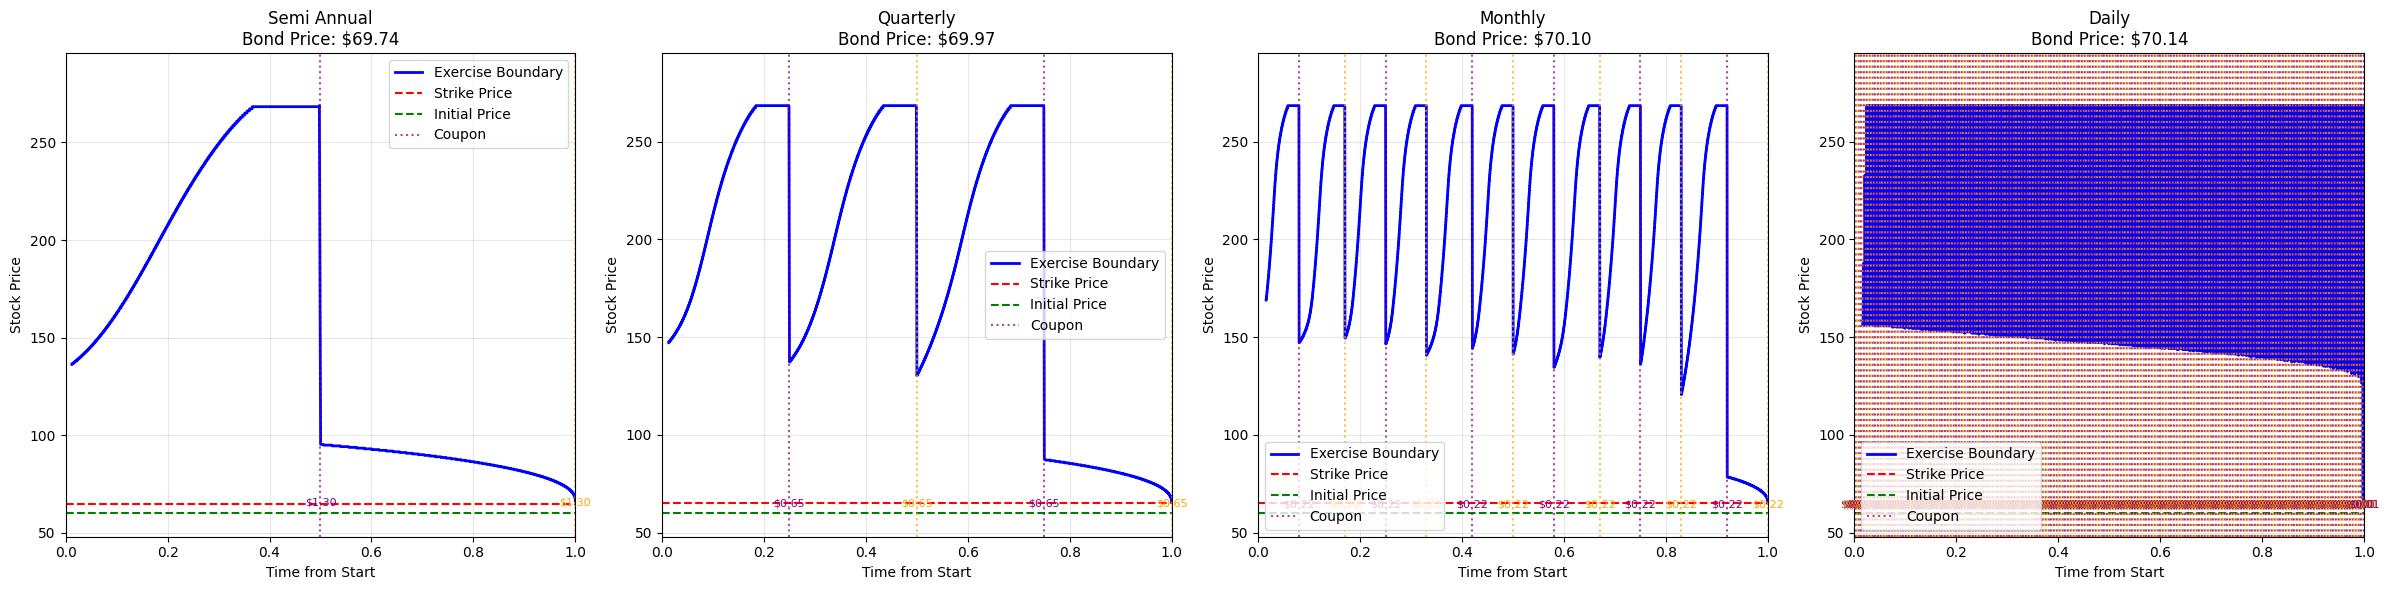


SUMMARY RESULTS - TRINOMIAL TREE
Coupon Structure Conversion Option Convertible Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual           $5.4088          $69.7432                2         $2.60        1.08
       Quarterly           $5.6156          $69.9657                4         $2.60        0.99
         Monthly           $5.7351          $70.0962               12         $2.60        0.98
           Daily           $5.7815          $70.1390              365         $2.59        0.94

BOUNDARY STATISTICS - TRINOMIAL TREE

Semi Annual:
  Min boundary: $66.30
  Max boundary: $268.90
  Avg boundary: $152.52
  Points: 16147/16385

Quarterly:
  Min boundary: $65.65
  Max boundary: $268.35
  Avg boundary: $185.86
  Points: 16128/16385

Monthly:
  Min boundary: $65.22
  Max boundary: $268.35
  Avg boundary: $211.07
  Points: 16108/16385

Daily:
  Min boundary: $65.01
  Max boundary: $268.35
  Avg boundary: $222.94
  Points: 16061/16385

KEY OBSERVATIONS - TRINOMIAL TR

In [11]:
def trinomial_tree_convertible_continuous(S0=60.0, K=65.0, T=1.0, sigma=0.3, r=0.05, q=0.02, 
                                        n=200, coupon_configs=None):
    """
    Trinomial tree for Convertible Bond with CONTINUOUS dividends and DISCRETE coupons
    Fixed logic: Coupon applied BEFORE exercise decision, time correctly tracked
    """
    print("=== Trinomial Tree - Convertible Bond with Continuous Dividends ===")
    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
    print(f"Time steps: {n}")
    
    if coupon_configs is None:
        coupon_configs = {
            'semi_annual': {'times': [0.5, 1.0], 'amounts': [1.3, 1.3]},
            'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [0.65, 0.65, 0.65, 0.65]},
            'monthly': {'times': [round(i/12, 2) for i in range(1, 13)], 'amounts': [0.2167] * 12},
            'daily': {'times': [round(i/365, 4) for i in range(1, 366)], 'amounts': [0.0071] * 365}
        }
    
    lambda_ = math.sqrt(3)
    dt = T / n
    h = lambda_ * sigma * math.sqrt(dt)
    
    # Adjust probabilities for continuous dividends: r - q
    mu_drift = (r - q - 0.5 * sigma**2) * math.sqrt(dt) / (2 * lambda_ * sigma)
    qu = 0.5 / (lambda_**2) + mu_drift
    qm = 1 - 1 / (lambda_**2)
    qd = 0.5 / (lambda_**2) - mu_drift
    
    discount = math.exp(-r * dt)
    offset = n
    
    def build_stock_grid(S0, n, h):
        """Build stock price grid"""
        Ss = np.zeros(2 * n + 1)
        for j in range(0, 2 * n + 1):
            Ss[j] = S0 * np.exp((n - j) * h)
        return Ss
    
    results = {}
    all_boundaries = {}
    
    for coupon_name, coupon_config in coupon_configs.items():
        print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
        coupon_times = coupon_config['times']
        coupon_amounts = coupon_config['amounts']
        
        # Convert coupon times to step indices (forward steps from 0)
        coupon_steps = {}
        for t, amount in zip(coupon_times, coupon_amounts):
            i_step = int(round(n * (t / T)))
            i_step = max(1, min(n, i_step))
            if i_step not in coupon_steps:
                coupon_steps[i_step] = 0
            coupon_steps[i_step] += amount
        
        print(f"Coupon payments: {len(coupon_times)} at times {coupon_times}")
        print(f"Coupon amounts: {coupon_amounts}")
        print(f"Step indices (forward): {sorted(coupon_steps.keys())}")
        
        start_time = time.perf_counter()
        
        # Build stock grid
        Ss = build_stock_grid(S0, n, h)
        Ss = np.clip(Ss, 0, S0 * np.exp(5 * sigma * np.sqrt(T)))  # Cap grid
        
        # Initialize value matrix
        V = np.zeros((n + 1, 2 * n + 1))
        
        # Terminal condition: max(S, K + final_coupon) at maturity
        final_coupon = coupon_steps.get(n, 0)
        V[n, :] = np.maximum(Ss, K + final_coupon)
        
        # Store exercise boundaries (time from 0 to T)
        boundaries = []
        
        # Backward induction: from i=n-1 down to i=0 (i is forward step)
        for i in range(n - 1, -1, -1):
            start_idx = offset - i
            end_idx = offset + i + 1
            
            # Current time from start
            current_time = i * dt
            
            # Expected continuation value
            continuation = discount * (
                qu * V[i + 1, start_idx - 1 : end_idx - 1] +  # up (lower j)
                qm * V[i + 1, start_idx : end_idx] +
                qd * V[i + 1, start_idx + 1 : end_idx + 1]    # down (higher j)
            )
            
            # Add coupon if paid at this time step (before decision)
            coupon = coupon_steps.get(i, 0)
            continuation += coupon
            
            # Current stock prices
            S_curr = Ss[start_idx:end_idx]
            
            # American conversion: max(S, continuation)
            conversion_value = S_curr
            V[i, start_idx:end_idx] = np.maximum(conversion_value, continuation)
            
            # Find exercise boundary (lowest S where exercise optimal)
            convert_optimal = conversion_value >= continuation
            reasonable_convert = convert_optimal & (S_curr > K * 0.5) & (S_curr < S0 * 5.0)
            
            if np.any(reasonable_convert):
                boundary_price = np.min(S_curr[reasonable_convert])
            else:
                boundary_price = np.nan
            
            boundaries.append((current_time, boundary_price))
        
        # Reverse boundaries to from T to 0? No, since loop from n-1 to 0, append is from near maturity to 0
        boundaries = list(reversed(boundaries))
        boundaries.append((T, max(K, K + final_coupon)))  # at maturity
        
        # Price at t=0
        price = V[0, offset]
        duration = time.perf_counter() - start_time
        
        # Components
        B = K * math.exp(-r * T)
        pv_coupons = sum(amount * math.exp(-r * t) for amount, t in zip(coupon_amounts, coupon_times))
        straight_bond = B + pv_coupons
        conversion_option = price - straight_bond
        
        # Store
        results[coupon_name] = {
            'convertible_price': price,
            'straight_bond': straight_bond,
            'conversion_option': conversion_option,
            'runtime': duration,
            'boundaries': boundaries
        }
        
        all_boundaries[coupon_name] = boundaries
        
        print(f"Conversion option value: {conversion_option:.6f}")
        print(f"Convertible bond price: {price:.6f}")
        print(f"Runtime: {duration:.2f}s")
    
    # Visualization...
    print("\n" + "="*50)
    print("EXERCISE BOUNDARY VISUALIZATION")
    print("="*50)
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for i, (coupon_name, boundaries) in enumerate(all_boundaries.items()):
        if boundaries:
            t_b, S_b = zip(*boundaries)
            valid_mask = ~np.isnan(S_b)
            t_valid = np.array(t_b)[valid_mask]
            S_valid = np.array(S_b)[valid_mask]
            
            axes[i].plot(t_valid, S_valid, 'b-', linewidth=2, label='Exercise Boundary')
            axes[i].axhline(y=K, color='r', linestyle='--', label='Strike Price')
            axes[i].axhline(y=S0, color='g', linestyle='--', label='Initial Price')
            
            coupon_times = coupon_configs[coupon_name]['times']
            coupon_amounts = coupon_configs[coupon_name]['amounts']
            
            for j, (ct, amount) in enumerate(zip(coupon_times, coupon_amounts)):
                color = 'purple' if j % 2 == 0 else 'orange'
                axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label='Coupon' if j==0 else None)
                y_pos = min(S_valid) * 0.95 if len(S_valid)>0 else S0 * 0.8
                axes[i].text(ct, y_pos, f'${amount:.2f}', ha='center', va='bottom', fontsize=8, color=color)
            
            axes[i].set_xlabel('Time from Start')
            axes[i].set_ylabel('Stock Price')
            title = f'{coupon_name.replace("_", " ").title()}\nBond Price: ${results[coupon_name]["convertible_price"]:.2f}'
            axes[i].set_title(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(S0 * 0.8, max(max(S_valid)*1.1 if len(S_valid)>0 else K*1.5, S0*1.5))
            axes[i].set_xlim(0, T)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY RESULTS - TRINOMIAL TREE")
    print("="*80)
    
    summary_data = []
    for coupon_name, result in results.items():
        summary_data.append({
            'Coupon Structure': coupon_name.replace('_', ' ').title(),
            'Conversion Option': f"${result['conversion_option']:.4f}",
            'Convertible Price': f"${result['convertible_price']:.4f}",
            'Coupon Payments': len(coupon_configs[coupon_name]['times']),
            'Total Coupons': f"${sum(coupon_configs[coupon_name]['amounts']):.2f}",
            'Runtime (s)': f"{result['runtime']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Boundary stats
    print("\n" + "="*80)
    print("BOUNDARY STATISTICS - TRINOMIAL TREE")
    print("="*80)
    
    for coupon_name, boundaries in all_boundaries.items():
        if boundaries:
            t_b, S_b = zip(*boundaries)
            S_valid = np.array([s for s in S_b if not np.isnan(s)])
            
            if len(S_valid) > 0:
                print(f"\n{coupon_name.replace('_', ' ').title()}:")
                print(f"  Min boundary: ${np.min(S_valid):.2f}")
                print(f"  Max boundary: ${np.max(S_valid):.2f}")
                print(f"  Avg boundary: ${np.mean(S_valid):.2f}")
                print(f"  Points: {len(S_valid)}/{len(boundaries)}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS - TRINOMIAL TREE")
    print("="*80)
    print(f"1. Continuous dividends (q={q}) via adjusted drift")
    print("2. Discrete coupons added before exercise decision")
    print("3. Terminal: max(S, K + final_coupon)")
    print("4. Conversion option = convertible - straight bond")
    print(f"5. Time steps (n={n}) for smoother boundaries")
    
    return results, all_boundaries

# Run the trinomial tree with continuous dividends
if __name__ == "__main__":
    # Parameters (matching your request)
    S0 = 60.0
    K = 65.0
    r = 0.05  # Risk-free rate
    sigma = 0.3
    T = 1.0
    q = 0.02  # Continuous dividend yield
    n = 16384  # Time steps
    
    # Coupon configurations (same as Monte Carlo)
    coupon_configs = {
        'semi_annual': {'times': [0.5, 1.0], 'amounts': [1.3, 1.3]},
        'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [0.65, 0.65, 0.65, 0.65]},
        'monthly': {'times': [round(i/12, 2) for i in range(1, 13)], 'amounts': [0.2167] * 12},
        'daily': {'times': [round(i/365, 4) for i in range(1, 366)], 'amounts': [0.0071] * 365}
    }
    
    # Run trinomial tree
    results, boundaries = trinomial_tree_convertible_continuous(
        S0=S0, K=K, T=T, sigma=sigma, r=r, q=q, n=n, coupon_configs=coupon_configs
    )